In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
caminho_arquivo = '../data/spotify_songs.csv'

df = pd.read_csv(caminho_arquivo)

# limiar_popularidade = 90

# # Aplicando o filtro: mantemos apenas as linhas onde a popularidade é maior que o limiar
# df_filtrado = df[df['popularity'] > limiar_popularidade].copy()

# # Dica: verifique quantos gêneros sobraram após esse filtro
# print(f"Número de gêneros originais: {df['track_genre'].nunique()}")
# print(f"Número de gêneros após filtro: {df_filtrado['track_genre'].nunique()}")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Mostra o tamanho do dataset antes da limpeza
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

# Supondo que as colunas se chamem 'track_name' e 'artists' (ajustem se estiver diferente no CSV de vocês)
# keep='first' diz ao Pandas para manter a primeira aparição da música e apagar as repetições
df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

# Mostra o tamanho após a limpeza
print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

# Substitui o dataframe antigo pelo limpo para seguir com o notebook
df = df_limpo.copy()

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


In [ ]:
def agrupar_macro_genero(genero):
    genero = str(genero).lower()
    
    # --- Rock & Metal ---
    if any(x in genero for x in ['rock', 'metal', 'punk', 'grunge', 'hardcore', 'rockabilly', 'goth', 'emo', 'grindcore', 'industrial', 'ska']):
        return 'Rock & Metal'
    
    # --- Eletrônica & Dance ---
    elif any(x in genero for x in ['house', 'techno', 'electro', 'edm', 'dance', 'trance', 'breakbeat', 'club', 'trip-hop', 'dubstep', 'idm', 'hardstyle', 'garage', 'disco']):
        return 'Eletronica & Dance'

    # --- Gospel ---
    elif any(x in genero for x in ['gospel', 'world-music']):
        return 'Gospel'
    
    # --- Hip-Hop & Rap ---
    elif any(x in genero for x in ['hip-hop', 'rap', 'dancehall', 'drum-and-bass']):
        return 'Hip-Hop & Rap'
    
    # --- Pop ---
    elif 'pop' in genero:
        return 'Pop'
    
    # --- Jazz, Blues & Soul ---
    elif any(x in genero for x in ['jazz', 'blues', 'soul', 'funk', 'r-n-b', 'groove']):
        return 'Jazz, Blues & Soul'
    
    # --- Música Regional & Folk ---
    elif any(x in genero for x in ['brazil', 'mpb', 'samba', 'pagode', 'forro', 'latin', 'latino', 'salsa', 'tango', 'spanish', 'reggaeton', 'reggae', 'sertanejo', 'dub', 'afrobeat']):
        return 'Latin'
    
    # --- Clássica & Instrumental ---
    elif any(x in genero for x in ['classical', 'opera', 'piano', 'ambient', 'new-age', 'guitar', 'acoustic']):
        return 'Classica & Instrumental'
    
    # --- Country & Americana ---
    elif any(x in genero for x in ['country', 'bluegrass', 'honky-tonk', 'singer-songwriter', 'folk']):
        return 'Country & Folk'

    # --- Country & Americana ---
    elif any(x in genero for x in ['indie', 'alternative']):
        return 'Indie & Alternative'
    
    # --- Ásia ---
    elif any(x in genero for x in ['j-pop', 'j-rock', 'k-pop', 'j-dance', 'j-idol', 'cantopop', 'mandopop', 'indian', 'malay', 'iranian', 'anime']):
        return 'Asian Pop'
    
    # --- Humor & Infantil ---
    elif any(x in genero for x in ['children', 'kids', 'disney', 'show-tunes']):
        return 'Humor & Infantil'
    
    # --- Vibe & Estudo ---
    elif any(x in genero for x in ['chill', 'happy', 'sad', 'sleep', 'study', 'party', 'romance']):
        return 'Vibe & Mood'

    # --- Europa ---
    elif any(x in genero for x in ['german', 'british', 'french', 'swedish', 'turkish']):
        return 'European'
    
    # --- Outros ---
    else:
        return str(genero).capitalize()

# Aplicando a função
df['macro_genre'] = df['track_genre'].apply(agrupar_macro_genero)

# Verifique o resultado
print(df['macro_genre'].value_counts())

macro_genre
Eletronica & Dance         15771
Rock & Metal               14173
Latin                      10446
Pop                         6360
Classica & Instrumental     5955
Vibe & Mood                 5854
Asian Pop                   4502
European                    3821
Humor & Infantil            3630
Country & Folk              3551
Jazz, Blues & Soul          2830
Hip-Hop & Rap               1574
Gospel                      1545
Comedy                       987
Indie & Alternative          345
Name: count, dtype: int64


In [ ]:
# def agrupar_macro_genero(genero):
#     # Transforma para minúsculo para evitar erros de digitação
#     genero = str(genero).lower()
    
#     # Regras de agrupamento
#     if 'rock' in genero or 'metal' in genero or 'punk' in genero or 'grunge' in genero:
#         return 'Rock/Metal'
    
#     elif 'pop' in genero:
#         return 'Pop'
    
#     elif 'house' in genero or 'techno' in genero or 'electro' in genero or 'edm' in genero:
#         return 'Eletronica/Dance'
    
#     elif 'hip-hop' in genero or 'rap' in genero:
#         return 'Rap/Hip-Hop'
    
#     elif 'jazz' in genero or 'classical' in genero or 'blues' in genero:
#         return 'Classica/Jazz'
    
#     else:
#         # Se não cair em nenhuma regra, vira "Outros" (ou vocês podem retornar o 'genero' original)
#         return 'Outros'

# # Aplica a função linha por linha usando o .apply()
# df['macro_genre'] = df['track_genre'].apply(agrupar_macro_genero)

# # Verificando quantos ficaram em cada macro-grupo
# print(df['macro_genre'].value_counts())

In [ ]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
# Definindo a matriz X
X = df.select_dtypes(include=['number'])
X = X.drop(columns=['Unnamed: 0','popularity', 'mode', 'key', 'duration_ms', 'tempo', 'time_signature'], errors='ignore')

# X.head()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.65670142, -0.67285088,  0.34835697, ...,  0.69742674,
         0.95572265, -1.75510121],
       [-0.78356832, -1.8134425 , -1.62893418, ..., -0.59878572,
        -0.74523169, -1.75510121],
       [-0.68229935, -1.06722493, -0.21491369, ..., -0.51808766,
        -1.30335734, -1.75510121],
       ...,
       [ 0.39227689, -1.1832173 , -0.43377488, ..., -0.68503176,
         1.0620323 , -0.42781663],
       [ 0.15598264, -0.49886233, -0.43264382, ...,  0.25358746,
        -0.19090282, -0.42781663],
       [-0.18720663, -0.57232417, -0.30351383, ..., -0.65779617,
         0.92914524, -0.42781663]], shape=(81344, 9))

In [ ]:
# Definindo o vetor y
le = LabelEncoder()
df['genero_codificado'] = le.fit_transform(df['track_genre'])

y = df['genero_codificado']
y.head()

0    1
1    1
2    1
3    1
4    1
Name: genero_codificado, dtype: int64

In [ ]:
# Dividindo treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Acurácia do modelo: 0.68

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.71      0.71       908
           1       0.78      0.76      0.77      1242
           2       0.95      0.84      0.89       225
           3       0.67      0.77      0.72       702
           4       0.75      0.87      0.80      3044
           5       0.54      0.32      0.40       791
           6       0.63      0.64      0.63       288
           7       0.60      0.28      0.38       317
           8       0.71      0.65      0.68       702
           9       0.46      0.09      0.15        67
          10       0.45      0.13      0.21       573
          11       0.59      0.67      0.63      2080
          12       0.45      0.46      0.45      1309
          13       0.70      0.78      0.74      2846
          14       0.88      0.75      0.81      1175

    accuracy                           0.68     16269
   macro avg       0.66   

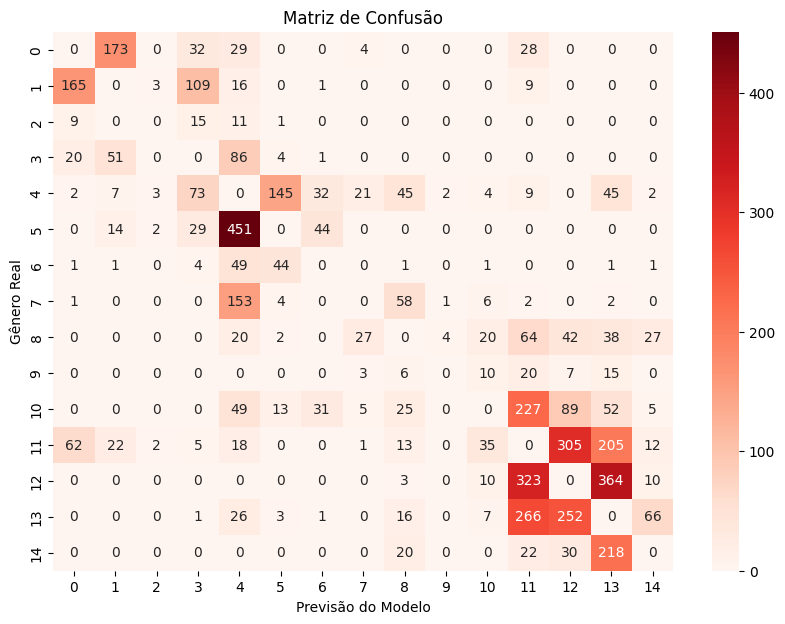

In [ ]:
# Modelo KNN
k = 10

knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2f}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

matriz_erros = conf_matrix.copy()

# 2. Zeramos a diagonal principal (onde ficam os acertos reais)
np.fill_diagonal(matriz_erros, 0)

plt.figure(figsize=(10, 7))
sns.heatmap(matriz_erros, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Gênero Real')
plt.title('Matriz de Confusão')
plt.show()

Acurácia do modelo: 0.63

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.71      0.56      0.62       908
           1       0.74      0.74      0.74      1242
           2       0.94      0.84      0.89       225
           3       0.54      0.70      0.61       702
           4       0.67      0.90      0.77      3044
           5       0.52      0.12      0.20       791
           6       0.53      0.45      0.49       288
           7       0.73      0.09      0.15       317
           8       0.70      0.47      0.56       702
           9       0.00      0.00      0.00        67
          10       0.45      0.03      0.06       573
          11       0.52      0.63      0.57      2080
          12       0.41      0.42      0.42      1309
          13       0.65      0.77      0.70      2846
          14       0.83      0.60      0.70      1175

    accuracy                           0.63     16269
   macro avg       0.60   

c:\.bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\.bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\.bibliotecas\LocalDocuments\02_Projetos\trabalho-iml-spotify\backend\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `

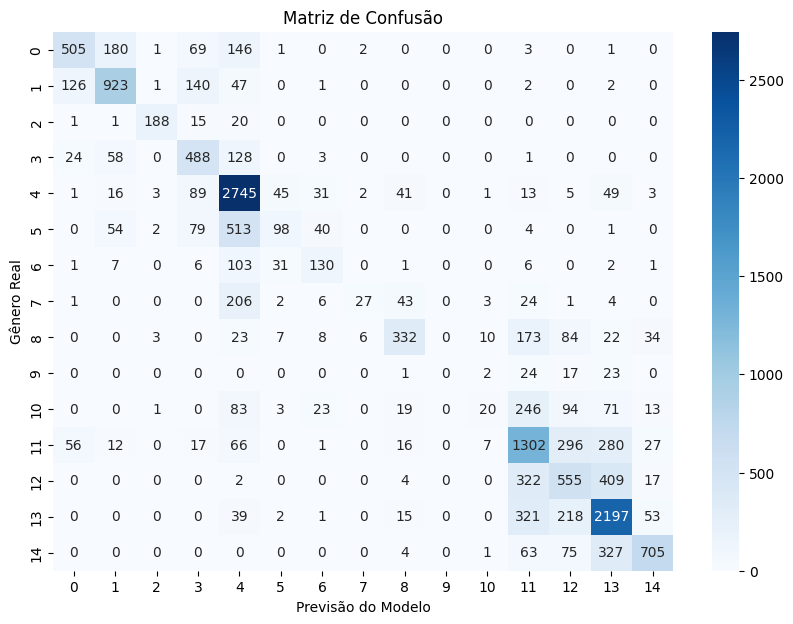

In [ ]:
k = 100

knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2f}")

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Gênero Real')
plt.title('Matriz de Confusão')
plt.show()

In [ ]:
generos = le.inverse_transform([i for i in range(15)])
print(generos)

['Asian Pop' 'Classica & Instrumental' 'Comedy' 'Country & Folk'
 'Eletronica & Dance' 'European' 'Gospel' 'Hip-Hop & Rap'
 'Humor & Infantil' 'Indie & Alternative' 'Jazz, Blues & Soul' 'Latin'
 'Pop' 'Rock & Metal' 'Vibe & Mood']


In [ ]:
# # 1. Gerar o relatório como um dicionário (passando os nomes reais dos géneros)
# # Lembrem-se de usar a vossa variável do LabelEncoder (ex: le.classes_)
# report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)

# # 2. Converter para DataFrame
# df_report = pd.DataFrame(report_dict).transpose()

# # 3. Remover as linhas de resumo (accuracy, macro avg, weighted avg) para ter apenas os géneros
# df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# # Visualizar as primeiras linhas para confirmar
# display(df_report.head())

In [ ]:
# # Tabela 1: Os 10 Géneros Mais Comuns (Maior Support)
# top_10_comuns = df_report.sort_values(by='support', ascending=False).head(10)

# print("--- TOP 10 GÉNEROS MAIS COMUNS NA BASE ---")
# display(top_10_comuns[['f1-score', 'support']])


# # Tabela 2: Os 10 Melhores F1-Scores (Filtro estatístico: mínimo de 20 exemplos)
# top_10_melhores = df_report[df_report['support'] > 20].sort_values(by='f1-score', ascending=False).head(10)

# print("\n--- TOP 10 MELHORES F1-SCORES (Abaixo de 20 exemplos ignorados) ---")
# display(top_10_melhores[['f1-score', 'support']])


# # Tabela 3: Os 10 Piores F1-Scores (Onde o modelo mais falha)
# top_10_piores = df_report[df_report['support'] > 20].sort_values(by='f1-score', ascending=True).head(10)

# print("\n--- TOP 10 PIORES F1-SCORES (Abaixo de 20 exemplos ignorados) ---")
# display(top_10_piores[['f1-score', 'support']])

In [ ]:

# 1. Simulando a entrada (Substitua pelas suas predições e nomes reais)
cm = confusion_matrix(y_test, y_pred)
classes = df['track_genre'].unique()


# 2. Preparar a Matriz de Confusão
cm_erros = cm.copy()
np.fill_diagonal(cm_erros, 0) # Removemos os acertos para focar só no erro

# 3. Criar o Grafo Direcionado
G = nx.DiGraph()

# 4. Adicionar as Arestas com um Limiar (Filtro)
# Para 100 classes, se você plotar todo erro de valor "1", vira um borrão.
# Defina um limiar para focar apenas nas confusões graves.
limiar_de_erro = 5 

for i in range(len(classes)):
    for j in range(len(classes)):
        peso = cm_erros[i, j]
        if peso >= limiar_de_erro:
            # Nó de origem (Real), Nó de destino (Predito), Força (Peso)
            G.add_edge(classes[i], classes[j], weight=peso)

# 5. Configurar o Layout (Onde a mágica acontece)
# O spring_layout aproxima os nós que têm conexões pesadas
pos = nx.spring_layout(G, k=0.8, iterations=100)

# 6. Desenhar o Grafo com Matplotlib
plt.figure(figsize=(16, 16))

# Desenhar os nós (ajuste o tamanho conforme a quantidade)
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='lightcoral', alpha=0.9)

# Desenhar as arestas com espessura variável baseada no peso
pesos = [G[u][v]['weight'] for u, v in G.edges()]
if pesos: # Evita erro se não houver arestas
    larguras = [ (p / max(pesos)) * 4 for p in pesos ] # Normaliza a espessura entre 0 e 4
else:
    larguras = 1

nx.draw_networkx_edges(G, pos, width=larguras, edge_color='gray', 
                       arrowstyle='->', arrowsize=15, alpha=0.6)

# Adicionar os nomes das classes
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title("Grafo de Confusões de Machine Learning", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()